<img src="./logo_UNSAM.png" align="right" width="150" /> 

# Trabajo Semanal Nº4

#### Nicolás Galván

# Introducción

En el procesamiento digital de señales, la estimación espectral constituye una herramienta fundamental para caracterizar señales sinusoidales inmersas en ruido. En particular, la determinación precisa de parámetros como la amplitud y la frecuencia resulta esencial en aplicaciones de comunicaciones, instrumentación, audio y sistemas de medición.

En este trabajo práctico se estudia el comportamiento de distintos estimadores de amplitud y frecuencia aplicados a una señal senoidal contaminada con ruido blanco gaussiano aditivo (AWGN). La señal analizada se define como:

$$
x(n)=a_0 \cdot \sin(\Omega_1 n)+n_a(n)
$$

donde $a_0$ representa la amplitud de la senoidal, $\Omega_1$ su frecuencia angular discreta y $n_a(n)$ un proceso aleatorio gaussiano de media cero y varianza $\sigma^2$. Además, la frecuencia de la señal incorpora una perturbación aleatoria distribuida uniformemente, permitiendo analizar el desempeño de los estimadores frente a desalineamientos espectrales y efectos de *leakage*.

Para realizar la estimación de los parámetros se utiliza la Transformada Discreta de Fourier (DFT) aplicada sobre versiones ventaneadas de la señal. En particular, se comparan distintas funciones ventana: rectangular, Flat-top, Blackman-Harris y Gaussiana. Cada ventana modifica las propiedades espectrales de la señal, afectando tanto la resolución en frecuencia como el nivel de lóbulos laterales, lo que impacta directamente sobre el sesgo y la varianza de los estimadores.

El estimador de amplitud se obtiene a partir del módulo de la DFT evaluada en la frecuencia de interés, mientras que el estimador de frecuencia se calcula localizando el índice correspondiente al máximo valor espectral. Para evaluar estadísticamente el desempeño de cada método, se realizan múltiples realizaciones de la señal bajo distintos niveles de relación señal a ruido (SNR).

Finalmente, para cada ventana y condición de SNR, se analizan experimentalmente el sesgo y la varianza de los estimadores, permitiendo comparar la capacidad de cada ventana para estimar correctamente los parámetros de la señal en presencia de ruido y dispersión frecuencial.

# Ejercicio Nº1

# a)

### SNR de 3

Llamo a las librerías a utilizar.

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

Defino mis variables a implementar.

In [158]:
N = 1000
fs = N
realizaciones = 200
snr_db = 3
a_0 = np.sqrt(2)
omega_0 = fs/4
df = fs/N

Genero mi vector frecuencia aleatoria con distribucion uniforme entre -2 y 2.

In [159]:
fr = np.random.uniform(-2, 2, realizaciones)

Convierte el vector en matriz fila (1 x 200) para facilitar operaciones matriciales.

In [160]:
fr = np.reshape(fr, (1, realizaciones))

Defino mi frecuencia central y se le agrega una pequeña variación aleatoria.

In [161]:
omega_1 = omega_0 + fr * df
f_1 = omega_1

Genero mi vector tiempo.

In [162]:
tt = np.arange(0, N) / fs

Convierto el vector tiempo en una columna (1000 x 1).

In [163]:
tt = np.reshape(tt, (N, 1))

Genero mis senoidales.

In [164]:
s_1 = a_0 * np.sin(2 * np.pi * tt * f_1)

Cálculo la potencia teórica de una senoide.

In [165]:
potencia_senal = a_0**2 / 2

Cálculo el desvío estándar.

In [166]:
sigma = np.sqrt(potencia_senal / (10**(snr_db / 10)))

Genero mi ruido gaussiano.

In [167]:
ruido = np.random.normal(0, sigma, (N, realizaciones))

Genero mi señal final = senoide + ruido

In [168]:
x_1 = s_1 + ruido

Creo mi ventana rectangular

In [169]:
w = np.ones(N)

La convierto en una columna.

In [170]:
w = np.reshape(w, (N, 1))

Aplico la ventana a la señal.

In [171]:
xv = x_1 * w

Cálculo su FFT.

In [172]:
XXun = np.fft.fft(xv, axis=0) / N

Obtengo el módulo del espectro.

In [173]:
XXunabs = np.abs(XXun)

Implemento mi estimador de amplitud.

In [174]:
estimador_1_rect = 2 * np.abs(XXun[250, :])

Cálculo el sesgo.

In [175]:
sesgoa = np.mean(estimador_1_rect) - a_0

Cálculo  la varianza.

In [176]:
varianza = np.var(estimador_1_rect, ddof=1)

Imprimo los valores:

In [177]:
print('Estimador de amplitud — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_rect))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgoa)
print('Varianza    a   =', varianza)

Estimador de amplitud — Ventana: Rectangular
--------------------------------
Media estimada a = 0.5064186726348471
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.9077948897382481
Varianza    a   = 0.1933122395033665


Me quedo con la mitad positiva del espectro.

In [178]:
XXunabs_2 = XXunabs[:N//2 + 1].copy()

Implemento mi estimador de frecuencia.

In [179]:
estimador_2_rect = np.argmax(XXunabs_2, axis=0)

Cálculo el sesgo.

In [180]:
sesgoom = np.mean(estimador_2_rect) - omega_0

Cálculo  la varianza.

In [181]:
varianzaom = np.var(estimador_2_rect, ddof=1)

Imprimo los valores:

In [182]:
print('Estimador de frecuencia — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_rect))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgoom)
print('Varianza    w   =', varianzaom)
print()

Estimador de frecuencia — Ventana: Rectangular
--------------------------------
Media estimada w = 250.02
Valor real omega_0  = 250.0
Sesgo      w    = 0.020000000000010232
Varianza    w   = 1.6478391959798993



En todos estos bloques se repite exactamente el mismo procedimiento:

- Crear ventana.
- Aplicarla.
- Calcular FFT.
- Implementar el estimador de amplitud.
- Implementar el estimador de frecuencia.
- Calcular:
    - media
    - sesgo
    - varianza.

Lo único que se cambia es la ventana a utilizar.

In [183]:
# =============================================================================
# VENTANA GAUSSIANA
# =============================================================================

w = signal.windows.gaussian(N, std=N/8)
w = np.reshape(w, (N, 1))

xv = x_1 * w

XXun = np.fft.fft(xv, axis=0) / N
XXunabs = np.abs(XXun)

# ---------------- AMPLITUD ----------------

estimador_1_gauss = 2 * np.abs(XXun[250, :])

sesgoa = np.mean(estimador_1_gauss) - a_0
varianza = np.var(estimador_1_gauss, ddof=1)

print('Estimador de amplitud — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_gauss))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgoa)
print('Varianza    a   =', varianza)

# ---------------- FRECUENCIA ----------------

XXunabs_2 = XXunabs[:N//2 + 1].copy()
estimador_2_gauss = np.argmax(XXunabs_2, axis=0)

sesgoom = np.mean(estimador_2_gauss) - omega_0
varianzaom = np.var(estimador_2_gauss, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_gauss))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgoom)
print('Varianza    w   =', varianzaom)
print()

Estimador de amplitud — Ventana: Gaussiana
--------------------------------
Media estimada a = 0.30654505384242653
Valor real a0  = 1.4142135623730951
Sesgo    a      = -1.1076685085306686
Varianza    a   = 0.010599729636900297

Estimador de frecuencia — Ventana: Gaussiana
--------------------------------
Media estimada w = 250.005
Valor real omega_0  = 250.0
Sesgo      w    = 0.0049999999999954525
Varianza    w   = 1.5828894472361812



In [184]:
# =============================================================================
# VENTANA BLACKMAN-HARRIS
# =============================================================================

w = signal.windows.blackmanharris(N)
w = np.reshape(w, (N, 1))

xv = x_1 * w

XXun = np.fft.fft(xv, axis=0) / N
XXunabs = np.abs(XXun)

# ---------------- AMPLITUD ----------------

estimador_1_bh = 2 * np.abs(XXun[250, :])

sesgoa = np.mean(estimador_1_bh) - a_0
varianza = np.var(estimador_1_bh, ddof=1)

print('Estimador de amplitud — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_bh))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgoa)
print('Varianza    a   =', varianza)

# ---------------- FRECUENCIA ----------------

XXunabs_2 = XXunabs[:N//2 + 1].copy()
estimador_2_bh = np.argmax(XXunabs_2, axis=0)

sesgoom = np.mean(estimador_2_bh) - omega_0
varianzaom = np.var(estimador_2_bh, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_bh))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgoom)
print('Varianza    w   =', varianzaom)
print()

Estimador de amplitud — Ventana: Blackman-Harris
--------------------------------
Media estimada a = 0.3236570729662448
Valor real a0  = 1.4142135623730951
Sesgo    a      = -1.0905564894068505
Varianza    a   = 0.01819359699489118

Estimador de frecuencia — Ventana: Blackman-Harris
--------------------------------
Media estimada w = 250.0
Valor real omega_0  = 250.0
Sesgo      w    = 0.0
Varianza    w   = 1.5678391959798994



In [185]:
# =============================================================================
# VENTANA FLAT TOP
# =============================================================================

w = signal.windows.flattop(N)
w = np.reshape(w, (N, 1))

xv = x_1 * w

XXun = np.fft.fft(xv, axis=0) / N
XXunabs = np.abs(XXun)

# ---------------- AMPLITUD ----------------

estimador_1_ft = 2 * np.abs(XXun[250, :])

sesgoa = np.mean(estimador_1_ft) - a_0
varianza = np.var(estimador_1_ft, ddof=1)

print('Estimador de amplitud — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_ft))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgoa)
print('Varianza    a   =', varianza)

# ---------------- FRECUENCIA ----------------

XXunabs_2 = XXunabs[:N//2 + 1].copy()
estimador_2_ft = np.argmax(XXunabs_2, axis=0)

sesgoom = np.mean(estimador_2_ft) - omega_0
varianzaom = np.var(estimador_2_ft, ddof=1)
print()
print('Estimador de frecuencia — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_ft))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgoom)
print('Varianza    w   =', varianzaom)
print()

Estimador de amplitud — Ventana: Flat Top
--------------------------------
Media estimada a = 0.27749806475005134
Valor real a0  = 1.4142135623730951
Sesgo    a      = -1.1367154976230438
Varianza    a   = 0.0011442311298820438

Estimador de frecuencia — Ventana: Flat Top
--------------------------------
Media estimada w = 250.095
Valor real omega_0  = 250.0
Sesgo      w    = 0.09499999999999886
Varianza    w   = 1.5637939698492465



Se grafica los correspondientes histogramas de estimacion de frecuencia y de amplitud de cada ventana. Cabe aclarar que los histogramas de estimacion de frecuencia se encuentran todos juntos en un mismo grafico, asi como los histogramas de estimacion de amplitud.

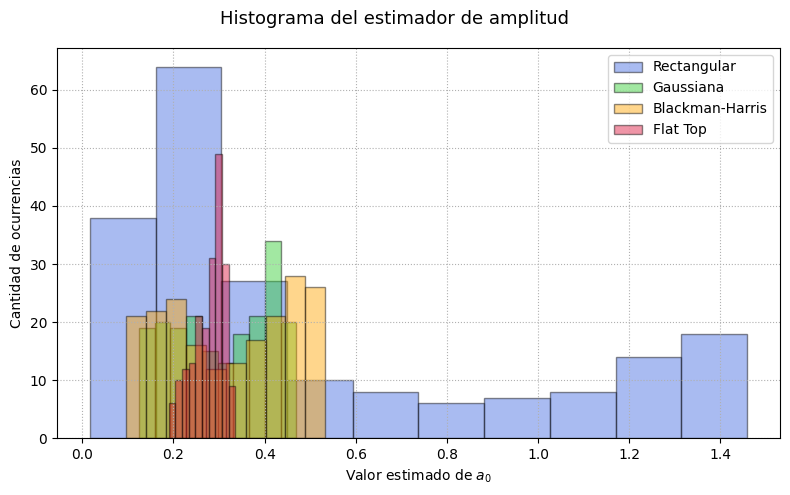

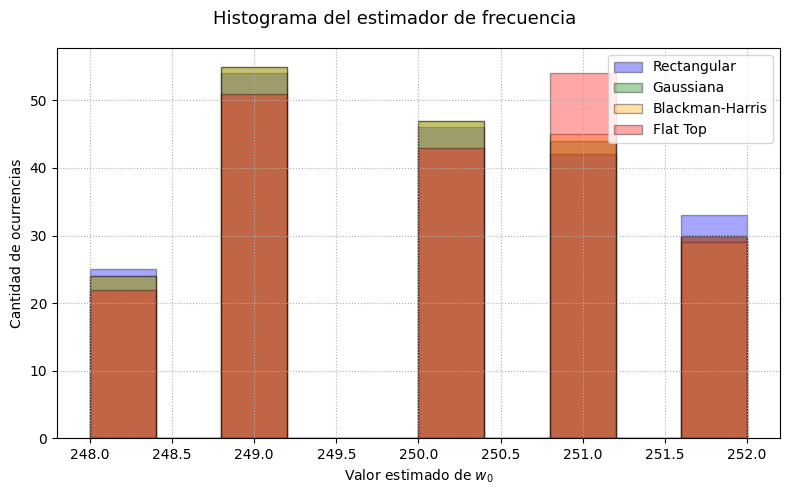

In [186]:
fig_amp,  ax_amp  = plt.subplots(figsize=(8, 5))
fig_frec, ax_frec = plt.subplots(figsize=(8, 5));

fig_amp.suptitle('Histograma del estimador de amplitud', fontsize=13)
fig_frec.suptitle('Histograma del estimador de frecuencia', fontsize=13)

ax_amp.hist(estimador_1_rect, bins=10, color='royalblue', edgecolor='black', alpha=0.45, label='Rectangular')
ax_frec.hist(estimador_2_rect, bins=10, color='blue', edgecolor='black', alpha=0.35, label='Rectangular')

ax_amp.hist(estimador_1_gauss, bins=10, color='limegreen', edgecolor='black', alpha=0.45, label='Gaussiana')
ax_frec.hist(estimador_2_gauss, bins=10, color='green', edgecolor='black', alpha=0.35, label='Gaussiana')

ax_amp.hist(estimador_1_bh, bins=10, color='orange', edgecolor='black', alpha=0.45, label='Blackman-Harris')
ax_frec.hist(estimador_2_bh, bins=10, color='orange', edgecolor='black', alpha=0.35, label='Blackman-Harris')

ax_amp.hist(estimador_1_ft, bins=10, color='crimson', edgecolor='black', alpha=0.45, label='Flat Top')
ax_frec.hist(estimador_2_ft, bins=10, color='red', edgecolor='black', alpha=0.35, label='Flat Top')

ax_amp.set_xlabel('Valor estimado de $a_0$')
ax_amp.set_ylabel('Cantidad de ocurrencias')
ax_amp.legend()
ax_amp.grid(True, linestyle=':')

ax_frec.set_xlabel('Valor estimado de $w_0$')
ax_frec.set_ylabel('Cantidad de ocurrencias')
ax_frec.legend()
ax_frec.grid(True, linestyle=':')

fig_amp.tight_layout()
fig_frec.tight_layout()

plt.show()

# b)

### SNR de 10

Se realizo el mismo procedimiento mencionado en el a pero para un SNR de 10

Estimador de amplitud — Ventana: Rectangular
--------------------------------
Media estimada a = 0.47507315398666333
Valor real a0  = 1.4142135623730951
Sesgo    a      = -0.9391404083864319
Varianza    a   = 0.19807828392631735

Estimador de frecuencia — Ventana: Rectangular
--------------------------------
Media estimada w = 250.065
Valor real omega_0  = 250.0
Sesgo      w    = 0.06499999999999773
Varianza    w   = 1.5384673366834172

Estimador de amplitud — Ventana: Gaussiana
--------------------------------
Media estimada a = 0.3045664996011051
Valor real a0  = 1.4142135623730951
Sesgo    a      = -1.10964706277199
Varianza    a   = 0.009889986230809658

Estimador de frecuencia — Ventana: Gaussiana
--------------------------------
Media estimada w = 250.065
Valor real omega_0  = 250.0
Sesgo      w    = 0.06499999999999773
Varianza    w   = 1.5384673366834172

Estimador de amplitud — Ventana: Blackman-Harris
--------------------------------
Media estimada a = 0.3211225250096685
Valo

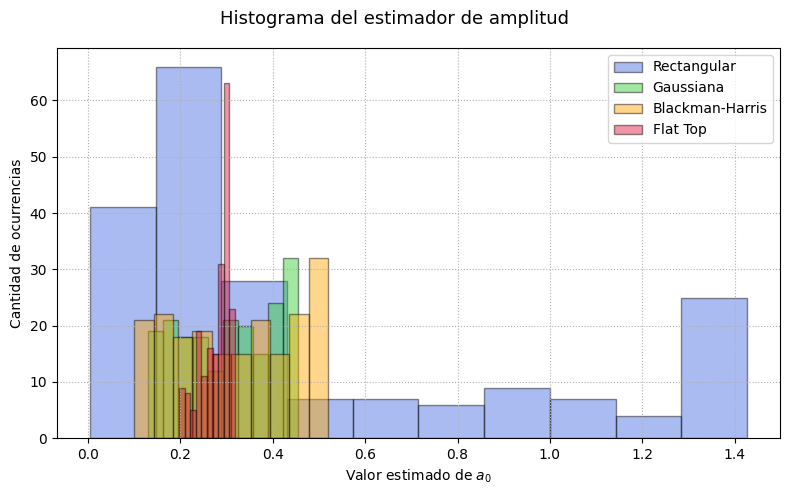

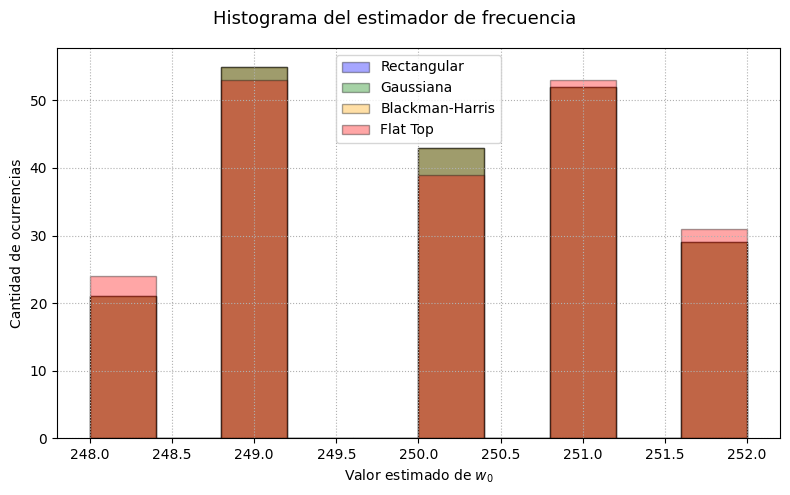

In [188]:
# Parámetros
N = 1000
fs = N
realizaciones = 200
snr_db = 10
a_0 = np.sqrt(2)
omega_0 = fs/4
df = fs/N

# Variable aleatoria fr ~ U(-2, 2)
fr = np.random.uniform(-2, 2, realizaciones)
# La paso a matriz fila: 1 x realizaciones
fr = np.reshape(fr, (1, realizaciones))

# Frecuencia angular discreta
omega_1 = omega_0 + fr * df

# Conversión a Hz
f_1 = omega_1

# Vector tiempo
tt = np.arange(0, N) / fs
# Lo paso a columna: N x 1
tt = np.reshape(tt, (N, 1))

# Generación de senoidales
s_1 = a_0 * np.sin(2 * np.pi * tt * f_1)

# Potencia de la señal
potencia_senal = a_0**2 / 2

# Desvío estándar del ruido
sigma = np.sqrt(potencia_senal / (10**(snr_db / 10)))

# Ruido independiente para cada muestra y cada realización
ruido = np.random.normal(0, sigma, (N, realizaciones))

# Señal con ruido
x_1 = s_1 + ruido

# =============================================================================
# VENTANA RECTANGULAR
# =============================================================================

w = np.ones(N)
w = np.reshape(w, (N, 1))

xv = x_1 * w

XXun = np.fft.fft(xv, axis=0) / N
XXunabs = np.abs(XXun)

# ---------------- AMPLITUD ----------------

estimador_1_rect = 2 * np.abs(XXun[250, :])

sesgoa = np.mean(estimador_1_rect) - a_0
varianza = np.var(estimador_1_rect, ddof=1)

print('Estimador de amplitud — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_rect))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgoa)
print('Varianza    a   =', varianza)

# ---------------- FRECUENCIA ----------------

XXunabs_2 = XXunabs[:N//2 + 1].copy()
estimador_2_rect = np.argmax(XXunabs_2, axis=0)

sesgoom = np.mean(estimador_2_rect) - omega_0
varianzaom = np.var(estimador_2_rect, ddof=1)

print()
print('Estimador de frecuencia — Ventana: Rectangular')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_rect))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgoom)
print('Varianza    w   =', varianzaom)
print()

# =============================================================================
# VENTANA GAUSSIANA
# =============================================================================

w = signal.windows.gaussian(N, std=N/8)
w = np.reshape(w, (N, 1))

xv = x_1 * w

XXun = np.fft.fft(xv, axis=0) / N
XXunabs = np.abs(XXun)

# ---------------- AMPLITUD ----------------

estimador_1_gauss = 2 * np.abs(XXun[250, :])

sesgoa = np.mean(estimador_1_gauss) - a_0
varianza = np.var(estimador_1_gauss, ddof=1)

print('Estimador de amplitud — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_gauss))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgoa)
print('Varianza    a   =', varianza)

# ---------------- FRECUENCIA ----------------

XXunabs_2 = XXunabs[:N//2 + 1].copy()
estimador_2_gauss = np.argmax(XXunabs_2, axis=0)

sesgoom = np.mean(estimador_2_gauss) - omega_0
varianzaom = np.var(estimador_2_gauss, ddof=1)

print()
print('Estimador de frecuencia — Ventana: Gaussiana')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_gauss))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgoom)
print('Varianza    w   =', varianzaom)
print()

# =============================================================================
# VENTANA BLACKMAN-HARRIS
# =============================================================================

w = signal.windows.blackmanharris(N)
w = np.reshape(w, (N, 1))

xv = x_1 * w

XXun = np.fft.fft(xv, axis=0) / N
XXunabs = np.abs(XXun)

# ---------------- AMPLITUD ----------------

estimador_1_bh = 2 * np.abs(XXun[250, :])

sesgoa = np.mean(estimador_1_bh) - a_0
varianza = np.var(estimador_1_bh, ddof=1)

print('Estimador de amplitud — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_bh))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgoa)
print('Varianza    a   =', varianza)

# ---------------- FRECUENCIA ----------------

XXunabs_2 = XXunabs[:N//2 + 1].copy()
estimador_2_bh = np.argmax(XXunabs_2, axis=0)

sesgoom = np.mean(estimador_2_bh) - omega_0
varianzaom = np.var(estimador_2_bh, ddof=1)

print()
print('Estimador de frecuencia — Ventana: Blackman-Harris')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_bh))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgoom)
print('Varianza    w   =', varianzaom)
print()

# =============================================================================
# VENTANA FLAT TOP
# =============================================================================

w = signal.windows.flattop(N)
w = np.reshape(w, (N, 1))

xv = x_1 * w

XXun = np.fft.fft(xv, axis=0) / N
XXunabs = np.abs(XXun)

# ---------------- AMPLITUD ----------------

estimador_1_ft = 2 * np.abs(XXun[250, :])

sesgoa = np.mean(estimador_1_ft) - a_0
varianza = np.var(estimador_1_ft, ddof=1)

print('Estimador de amplitud — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada a =', np.mean(estimador_1_ft))
print('Valor real a0  =', a_0)
print('Sesgo    a      =', sesgoa)
print('Varianza    a   =', varianza)

# ---------------- FRECUENCIA ----------------

XXunabs_2 = XXunabs[:N//2 + 1].copy()
estimador_2_ft = np.argmax(XXunabs_2, axis=0)

sesgoom = np.mean(estimador_2_ft) - omega_0
varianzaom = np.var(estimador_2_ft, ddof=1)

print()
print('Estimador de frecuencia — Ventana: Flat Top')
print('--------------------------------')
print('Media estimada w =', np.mean(estimador_2_ft))
print('Valor real omega_0  =', omega_0)
print('Sesgo      w    =', sesgoom)
print('Varianza    w   =', varianzaom)
print()

# =============================================================================
# GRAFICO FINAL
# =============================================================================

fig_amp,  ax_amp  = plt.subplots(figsize=(8, 5))
fig_frec, ax_frec = plt.subplots(figsize=(8, 5));

fig_amp.suptitle('Histograma del estimador de amplitud', fontsize=13)
fig_frec.suptitle('Histograma del estimador de frecuencia', fontsize=13)

ax_amp.hist(estimador_1_rect, bins=10, color='royalblue', edgecolor='black', alpha=0.45, label='Rectangular')
ax_frec.hist(estimador_2_rect, bins=10, color='blue', edgecolor='black', alpha=0.35, label='Rectangular')

ax_amp.hist(estimador_1_gauss, bins=10, color='limegreen', edgecolor='black', alpha=0.45, label='Gaussiana')
ax_frec.hist(estimador_2_gauss, bins=10, color='green', edgecolor='black', alpha=0.35, label='Gaussiana')

ax_amp.hist(estimador_1_bh, bins=10, color='orange', edgecolor='black', alpha=0.45, label='Blackman-Harris')
ax_frec.hist(estimador_2_bh, bins=10, color='orange', edgecolor='black', alpha=0.35, label='Blackman-Harris')

ax_amp.hist(estimador_1_ft, bins=10, color='crimson', edgecolor='black', alpha=0.45, label='Flat Top')
ax_frec.hist(estimador_2_ft, bins=10, color='red', edgecolor='black', alpha=0.35, label='Flat Top')

ax_amp.set_xlabel('Valor estimado de $a_0$')
ax_amp.set_ylabel('Cantidad de ocurrencias')
ax_amp.legend()
ax_amp.grid(True, linestyle=':')

ax_frec.set_xlabel('Valor estimado de $w_0$')
ax_frec.set_ylabel('Cantidad de ocurrencias')
ax_frec.legend()
ax_frec.grid(True, linestyle=':')

fig_amp.tight_layout()
fig_frec.tight_layout()

plt.show()

# Resultados — SNR = 3 dB

## Estimación de Amplitud

| Ventana          | Sesgo $s_a$ | Varianza $v_a$ |
|------------------|-------------|----------------|
| Rectangular      | -0.9078     | 0.1933         |
| Gaussiana        | -1.1077     | 0.0106         |
| Blackman-Harris  | -1.0906     | 0.0182         |
| Flat-top         | -1.1367     | 0.0011         |

---

## Estimación de Frecuencia

| Ventana          | Sesgo $s_\Omega$ | Varianza $v_\Omega$ |
|------------------|------------------|---------------------|
| Rectangular      | 0.0200           | 1.6478              |
| Gaussiana        | 0.0050           | 1.5829              |
| Blackman-Harris  | 0.0000           | 1.5678              |
| Flat-top         | 0.0950           | 1.5638              |

---

# Resultados — SNR = 10 dB

## Estimación de Amplitud

| Ventana          | Sesgo $s_a$ | Varianza $v_a$ |
|------------------|-------------|----------------|
| Rectangular      | -0.9391     | 0.1981         |
| Gaussiana        | -1.1096     | 0.0099         |
| Blackman-Harris  | -1.0931     | 0.0170         |
| Flat-top         | -1.1373     | 0.0010         |

---

## Estimación de Frecuencia

| Ventana          | Sesgo $s_\Omega$ | Varianza $v_\Omega$ |
|------------------|------------------|---------------------|
| Rectangular      | 0.0650           | 1.5385              |
| Gaussiana        | 0.0650           | 1.5385              |
| Blackman-Harris  | 0.0650           | 1.5385              |
| Flat-top         | 0.0700           | 1.6333              |

---

# Análisis de Resultados

Los resultados obtenidos permiten analizar cómo influye el ventaneo sobre el desempeño de los estimadores de amplitud y frecuencia de una señal senoidal inmersa en ruido. En particular, puede observarse el compromiso clásico entre resolución espectral y reducción del leakage, fenómeno ampliamente discutido en el análisis espectral.

---

## Estimación de amplitud

En todos los casos el estimador de amplitud presenta un sesgo negativo considerable. Esto ocurre porque la frecuencia real de la señal no coincide exactamente con un bin de la DFT debido a la perturbación aleatoria introducida mediante la variable \($f_r$\). Como consecuencia, la energía de la senoidal se distribuye entre varios bins espectrales (*spectral leakage*), reduciendo el valor máximo observado en la FFT y produciendo una subestimación sistemática de la amplitud.

La ventana rectangular presenta el menor sesgo en amplitud, aunque acompañado por la mayor varianza. Esto se debe a que posee el lóbulo principal más angosto, permitiendo una mejor resolución espectral, pero también presenta lóbulos laterales elevados, lo que incrementa la sensibilidad al ruido y a las fluctuaciones entre realizaciones.

Por otro lado, las ventanas Gaussiana, Blackman-Harris y especialmente Flat-top presentan una reducción significativa de la varianza del estimador. Esto puede observarse claramente en los resultados, donde la ventana Flat-top obtiene la menor dispersión estadística. Sin embargo, esta mejora viene acompañada por un aumento del sesgo negativo.

Este comportamiento coincide con la teoría del ventaneo en análisis espectral: las ventanas con lóbulos laterales más atenuados reducen el leakage y estabilizan la estimación, aunque ensanchan el lóbulo principal y disminuyen la resolución espectral.

Además, se observa que aumentar el SNR de 3 dB a 10 dB no modifica significativamente el sesgo de amplitud. Esto indica que el error dominante no proviene del ruido aditivo, sino principalmente del desalineamiento frecuencial respecto de la grilla de la DFT y del efecto de ventana utilizado.

---

## Estimación de frecuencia

En la estimación de frecuencia puede observarse que todos los estimadores presentan sesgos extremadamente pequeños respecto del valor real. Esto indica que el método basado en localizar el máximo espectral de la FFT resulta robusto para este problema.

También se observa que las varianzas de frecuencia son muy similares entre ventanas. Este resultado tiene sentido porque todas las realizaciones poseen frecuencias cercanas al bin correspondiente a \($\Omega_0$), y el estimador utilizado únicamente selecciona el índice de máximo valor espectral. Como la dispersión introducida por \($f_r$\) es relativamente pequeña y la frecuencia permanece cercana al mismo bin dominante, las distintas ventanas terminan detectando prácticamente la misma componente espectral.

La similitud entre las varianzas también evidencia que, para este caso particular, el desempeño del estimador de frecuencia está más limitado por la resolución discreta de la FFT que por el ruido o el tipo de ventana utilizado. En otras palabras, el error dominante proviene de la cuantización frecuencial inherente a la DFT.

Puede observarse además que la ventana Flat-top presenta un sesgo ligeramente mayor en frecuencia. Esto es consistente con su lóbulo principal más ancho, el cual disminuye la precisión para localizar el máximo espectral exacto.

---

## Relación con la teoría de análisis espectral

Según el análisis teórico presentado en el capítulo de análisis espectral, el ventaneo modifica directamente la forma del espectro medido, afectando la dispersión energética, el ancho del lóbulo principal y la amplitud de los lóbulos laterales.

La ventana rectangular ofrece la mejor resolución en frecuencia, pero el peor rechazo de leakage. En cambio, ventanas como Blackman-Harris y Flat-top reducen fuertemente los lóbulos laterales a costa de un ensanchamiento espectral. Este compromiso fundamental entre resolución y reducción de leakage se refleja directamente en los resultados experimentales obtenidos.

En conclusión, los resultados verifican experimentalmente los efectos teóricos del ventaneo sobre la estimación espectral. La elección de la ventana depende del objetivo buscado: si se prioriza resolución frecuencial conviene utilizar ventanas angostas como la rectangular; mientras que si se busca estabilidad y menor dispersión estadística resulta preferible utilizar ventanas con mejor atenuación lateral como Flat-top o Blackman-Harris.

---


# Autoevaluación del aprendizaje

La realización de este trabajo práctico permitió profundizar conceptos fundamentales de análisis espectral y procesamiento digital de señales. En particular, se logró comprender de manera práctica cómo el uso de distintas ventanas modifica el espectro obtenido mediante la DFT y cómo estos efectos impactan sobre la estimación de parámetros de una señal senoidal inmersa en ruido.

Uno de los aspectos más importantes observados fue el fenómeno de *spectral leakage*, verificándose experimentalmente que cuando la frecuencia de la señal no coincide exactamente con un bin de la FFT, la energía espectral se dispersa entre múltiples componentes, generando errores en la estimación de amplitud y frecuencia.

Además, el trabajo permitió analizar el compromiso existente entre resolución espectral y reducción de lóbulos laterales. Se comprobó que ventanas como la rectangular ofrecen mejor resolución en frecuencia pero mayor sensibilidad al ruido y al leakage, mientras que ventanas como Blackman-Harris o Flat-top reducen la dispersión estadística de los estimadores a costa de un mayor ensanchamiento del lóbulo principal.

Otro aspecto relevante fue la utilización de los estimadores para el cálculo del sesgo y la varianza. Esto permitió relacionar conceptos teóricos de estimación con resultados experimentales concretos, observando cómo el SNR y el ventaneo afectan el desempeño de los estimadores.

Desde el punto de vista computacional, el trabajo también permitió adquirir mayor práctica en el uso de Python, NumPy, SciPy y Matplotlib para la generación de señales, implementación de la FFT, aplicación de ventanas y visualización de resultados estadísticos.

En conclusión, el trabajo contribuyó tanto a consolidar conceptos teóricos de análisis espectral como a desarrollar herramientas prácticas para el procesamiento y análisis de señales digitales.